---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/PDI_python/blob/main/topico3/Topico3.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

---

In [ ]:
### !!! Executar esta célula primeiro, se dentro do Colab
# Quando dentro do Colab, clonar o repositório completo para garantir acesso à pasta de imagens
!git clone https://github.com/ppestana-supervisor/PDI_python.git
%cd PDI_python/topico5

# 05 · Transformers e CLIP
Neste notebook, vamos explorar embeddings visuais com Vision Transformers (ViT) e o modelo multimodal CLIP. Estes modelos permitem realizar tarefas como classificação zero-shot, busca por similaridade sem treino adicional, e visualização de relações semânticas entre imagens e texto.

## 1. Importações e configuração

Esta célula configura o ambiente necessário para explorar **modelos baseados em Transformers aplicados a visão**, com foco no **Vision Transformer (ViT)** e no **CLIP** (*Contrastive Language–Image Pretraining*).

1. **Bibliotecas centrais de PyTorch e TorchVision:**  
   - `torch` e `torchvision` são usados para manipular tensores e imagens, carregar datasets e aplicar transformações.  
   - `vit_b_16` é um modelo Vision Transformer pré-treinado incluído no TorchVision, representando a arquitetura típica de atenção visual.

2. **Biblioteca OpenCLIP:**  
   - `open_clip` permite aceder a versões abertas do modelo **CLIP**, que integra visão e linguagem — mapeando imagens e textos num espaço vetorial partilhado.  
   - Este modelo será explorado para comparar embeddings visuais e semânticos.

3. **Ferramentas de análise e visualização:**  
   - `PCA` (Análise de Componentes Principais) e `TSNE` (t-Distributed Stochastic Neighbor Embedding) reduzem a dimensionalidade dos embeddings, permitindo representá-los em 2D para visualização.  
   - `matplotlib` e `numpy` tratam da geração de gráficos e manipulação numérica.

4. **Manipulação de imagens e ficheiros:**  
   - `PIL.Image` lida com a leitura e conversão de imagens.  
   - `os` facilita o acesso a diretórios locais de imagens, caso sejam usados exemplos externos.

**Nota pedagógica:**  
Este notebook introduz o paradigma **Transformer em visão computacional**, contrastando com as CNNs usadas nos notebooks anteriores.  
Os Transformers captam **relações globais entre regiões da imagem** através de mecanismos de autoatenção, e o CLIP estende este conceito à **associação entre imagens e texto**, permitindo realizar tarefas de correspondência e busca multimodal.  
A partir daqui, o foco será compreender o que significa representar uma imagem não apenas como uma grelha de píxeis, mas como um **vetor semântico contextual**.

In [1]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torchvision.models import vit_b_16
import open_clip
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
from PIL import Image
import os

/Users/pedropestana/anaconda3/envs/ml_imagem/lib/python3.10/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


## 2. Carregamento do modelo CLIP

Esta célula inicializa o modelo **CLIP (Contrastive Language–Image Pretraining)**, um dos marcos mais importantes na aprendizagem multimodal.  
O CLIP combina uma rede visual (neste caso, um **Vision Transformer ViT-B/32**) e um modelo de linguagem, treinados em conjunto para associar imagens e descrições textuais.

1. **Criação do modelo e transformações associadas:**  
   - `open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')` carrega a arquitetura CLIP baseada no **Vision Transformer base (ViT-B)** com *patch size* 32×32, e aplica os pesos originais treinados pela OpenAI.  
   - O objeto `preprocess` contém as transformações padrão (redimensionamento, normalização e conversão para tensor) necessárias para preparar as imagens antes de as passar pelo modelo.

2. **Tokenizador textual:**  
   - `open_clip.get_tokenizer('ViT-B-32')` fornece o tokenizador correspondente ao modelo, que converte frases ou palavras em vetores numéricos (tokens) compreendidos pela parte linguística do CLIP.

3. **Modo de avaliação:**  
   - `model.eval()` coloca o modelo em modo de inferência, desativando comportamentos específicos de treino (como *dropout*), garantindo previsões determinísticas.

**Nota pedagógica:**  
O CLIP aprende representações conjuntas de imagens e texto — ou seja, projeta ambos num **espaço vetorial partilhado**, onde uma imagem e uma descrição coerente (“uma foto de um cão”) ficam próximas, enquanto pares incoerentes (“um avião” e “um gato”) ficam afastados.  
Este princípio permite realizar tarefas de **pesquisa sem treino adicional** (*zero-shot learning*), bastando comparar similaridades entre embeddings de imagens e frases.

In [2]:
model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai', quick_gelu=True
)
tokenizer = open_clip.get_tokenizer('ViT-B-32')
model.eval();

/Users/pedropestana/anaconda3/envs/ml_imagem/lib/python3.10/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


## 3. Dataset e extração de embeddings

Esta célula aplica o modelo CLIP a um conjunto de imagens reais (CIFAR-10) para extrair **representações vetoriais de alto nível** — os chamados *image embeddings*.  
Cada imagem é convertida num vetor num espaço semântico onde imagens semelhantes ficam próximas entre si.

1. **Carregamento do dataset:**  
   - `datasets.CIFAR10` fornece um conjunto padrão de 10 classes (avião, automóvel, pássaro, gato, etc.), usado aqui apenas para demonstração.  
   - As imagens são automaticamente processadas com `preprocess`, o pipeline de normalização e redimensionamento definido pelo CLIP.

2. **Criação do *DataLoader*:**  
   - O `DataLoader` permite iterar sobre o dataset em *batches* de 32 imagens, garantindo uma passagem eficiente pelo modelo sem sobrecarregar a memória.

3. **Extração dos *embeddings*:**  
   - Dentro do bloco `torch.no_grad()` (sem cálculo de gradientes, pois não há treino), cada lote de imagens é passado por `model.encode_image(images)`.  
   - O método devolve um vetor de características para cada imagem, representando o seu conteúdo visual no espaço multimodal do CLIP.  
   - Os resultados são acumulados em listas (`image_embeddings`, `image_labels`) e convertidos em arrays NumPy no final.

**Nota pedagógica:**  
Os *embeddings* produzidos pelo CLIP não descrevem apenas textura ou cor, mas captam **conceitos visuais abstratos** aprendidos durante o treino multimodal com milhões de pares imagem–texto.  
Assim, duas imagens de “aviões” terão vetores semelhantes, mesmo que nunca tenham sido vistas juntas, refletindo uma **semelhança semântica** e não apenas visual.  
Estes vetores poderão ser reduzidos e visualizados (por PCA ou t-SNE) nas próximas células para explorar a estrutura latente do espaço de representação.

In [3]:
dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=preprocess)
loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=False)

image_embeddings = []
image_labels = []

with torch.no_grad():
    for images, labels in loader:
        emb = model.encode_image(images)
        image_embeddings.append(emb.cpu())
        image_labels.extend(labels.numpy())

image_embeddings = torch.cat(image_embeddings).numpy()
image_labels = np.array(image_labels)

## 4. Visualização com PCA e t-SNE

Esta célula reduz os *embeddings* extraídos pelo CLIP a duas dimensões e representa cada ponto com a sua imagem correspondente — uma forma intuitiva de observar a **organização semântica** do espaço de representação aprendido pelo modelo.

1. **Seleção e configuração:**  
   - É usado um subconjunto de 100 imagens do CIFAR-10 (`subset_size=100`) para manter o gráfico legível.  
   - O parâmetro `zoom` controla o tamanho das miniaturas (*thumbnails*) e `jitter_strength` adiciona ligeira aleatoriedade para evitar sobreposição exata entre pontos.

2. **Desnormalização das imagens:**  
   - A função `denormalize` inverte a normalização padrão do CLIP (baseada nos valores médios e desvios de ImageNet), restaurando as cores originais das imagens antes da exibição.

3. **Redução de dimensionalidade (PCA):**  
   - O `PCA` projeta os *embeddings* de alta dimensão num plano 2D.  
   - Este processo não altera as relações semânticas essenciais, mas permite visualizar a estrutura global do espaço vetorial aprendido.  
   - Um leve *jitter* é adicionado para facilitar a distinção entre pontos coincidentes.

4. **Visualização com thumbnails:**  
   - Cada ponto no gráfico é substituído pela imagem correspondente, através de `OffsetImage` e `AnnotationBbox`.  
   - O resultado é um mapa bidimensional onde **imagens semanticamente próximas aparecem agrupadas**, mesmo que pertençam a classes diferentes no dataset original.

**Nota pedagógica:**  
Este tipo de visualização é uma ferramenta poderosa para **compreender o espaço latente dos modelos multimodais**.  
A proximidade entre imagens não depende de cor ou textura, mas de significado aprendido — por exemplo, aviões e helicópteros podem surgir próximos, enquanto carros e caminhões formam outro grupo distinto.  
O PCA é apenas uma aproximação linear, mas já revela a notável **estrutura semântica auto-organizada** do CLIP, resultado do treino conjunto de imagens e texto em larga escala.

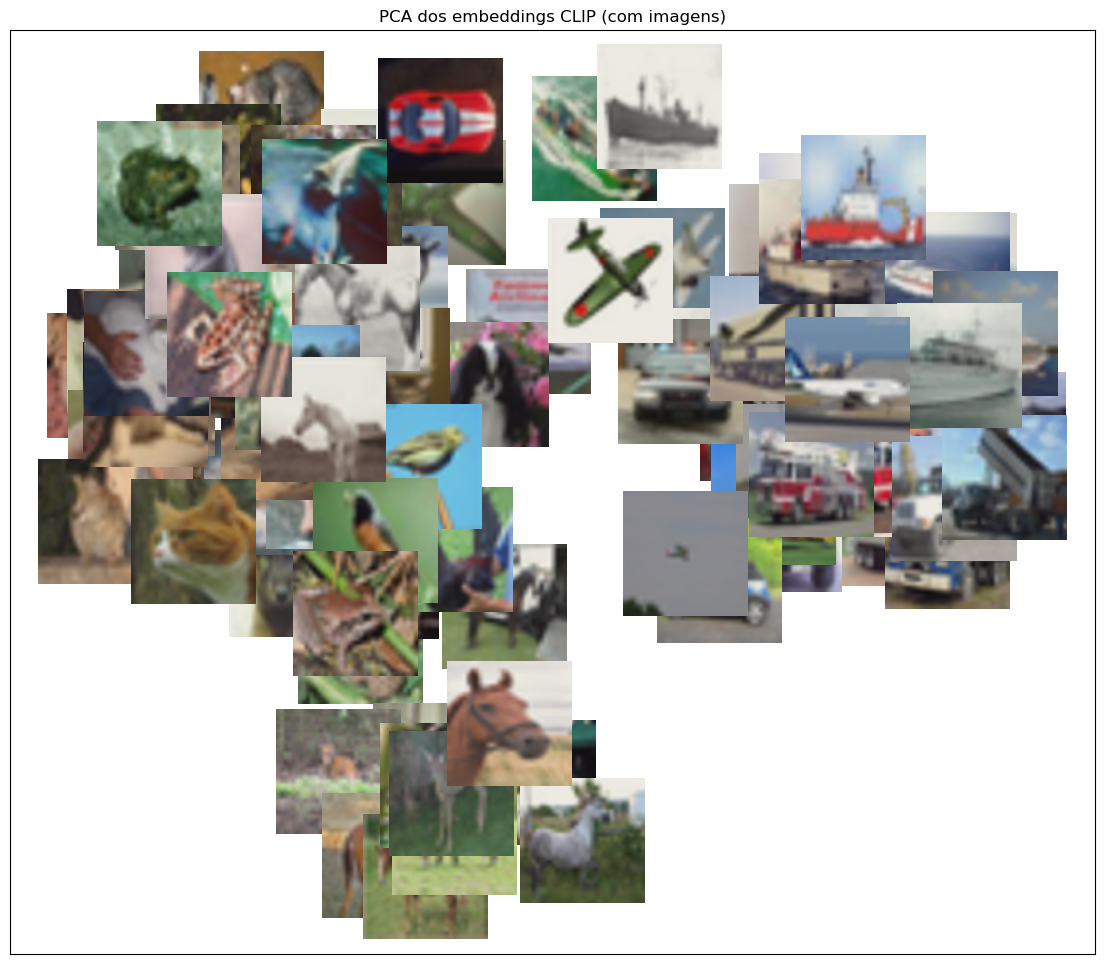

In [4]:
subset_size = 100
zoom = 0.4
jitter_strength = 0.05

def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    return torch.clamp(img, 0, 1)

embeddings = image_embeddings[:subset_size]
labels = image_labels[:subset_size]

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)

jitter = np.random.normal(scale=jitter_strength, size=emb_2d.shape)
emb_2d += jitter

subset_imgs = [dataset[i][0] for i in range(subset_size)]

def plot_with_thumbnails(emb_2d, images, zoom=0.5):
    fig, ax = plt.subplots(figsize=(14, 12))  # 🔍 aumentar figura
    ax.set_title("PCA dos embeddings CLIP (com imagens)")

    for (x, y), img in zip(emb_2d, images):
        img = denormalize(img)
        im = np.transpose(img.numpy(), (1, 2, 0))
        imagebox = OffsetImage(im, zoom=zoom)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False)
        ax.add_artist(ab)

    ax.set_xticks([])
    ax.set_yticks([])

    # Expande os limites do gráfico para que thumbnails não fiquem cortados
    buffer_x = (emb_2d[:, 0].max() - emb_2d[:, 0].min()) * 0.1
    buffer_y = (emb_2d[:, 1].max() - emb_2d[:, 1].min()) * 0.1
    ax.set_xlim(emb_2d[:, 0].min() - buffer_x, emb_2d[:, 0].max() + buffer_x)
    ax.set_ylim(emb_2d[:, 1].min() - buffer_y, emb_2d[:, 1].max() + buffer_y)

    plt.show()

plot_with_thumbnails(emb_2d, subset_imgs, zoom=zoom)

## 5. Classificação zero-shot

Esta célula demonstra uma das capacidades mais marcantes do CLIP: a **classificação zero-shot**, isto é, identificar o conteúdo de uma imagem **sem treino adicional**.  
O modelo compara diretamente a imagem com descrições textuais e escolhe a mais semelhante no seu espaço multimodal.

1. **Geração de prompts textuais:**  
   - É criada uma lista de descrições simples (`a photo of a {classe}`) para as 10 classes do CIFAR-10.  
   - Cada frase é convertida em tokens pelo `tokenizer`, resultando em representações numéricas compreendidas pela componente textual do CLIP.

2. **Codificação dos textos:**  
   - `model.encode_text(text_inputs)` produz vetores (embeddings) normalizados que representam o significado de cada descrição.  
   - A normalização (`text_features /= …`) assegura que todas as representações tenham a mesma escala, permitindo comparações justas com embeddings de imagem.

3. **Codificação da imagem:**  
   - Uma única imagem é obtida do dataset (`dataset[0]`) e processada pelo mesmo modelo (`encode_image`), gerando um vetor no mesmo espaço semântico.  
   - Este vetor também é normalizado.

4. **Cálculo da similaridade imagem-texto:**  
   - O produto interno entre o vetor da imagem e os vetores de texto (`image_features @ text_features.T`) mede a proximidade semântica.  
   - A função *softmax* converte esses valores em probabilidades relativas de correspondência.  
   - A classe com maior probabilidade é escolhida como previsão.

**Nota pedagógica:**  
O CLIP realiza aqui uma forma de **aprendizagem por correspondência** — em vez de associar explicitamente rótulos, ele compara **significados** entre imagens e descrições.  
Isso permite aplicar o modelo a **novas categorias nunca vistas**, bastando fornecer novas frases descritivas.  
Trata-se de uma transição conceptual importante: a classificação deixa de depender de treino supervisionado e passa a apoiar-se em **similaridade semântica entre modalidades**.

In [5]:
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
text_inputs = tokenizer([f"a photo of a {c}" for c in classes])
with torch.no_grad():
    text_features = model.encode_text(text_inputs)
    text_features /= text_features.norm(dim=-1, keepdim=True)

sample_img, true_label = dataset[0]
image_input = sample_img.unsqueeze(0)  # só adiciona dimensão batch

image_features = model.encode_image(image_input)
image_features /= image_features.norm(dim=-1, keepdim=True)

similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
predicted_class = classes[similarity.argmax()]

## 6. Busca de imagem por texto

Esta célula demonstra o poder multimodal do CLIP ao realizar uma **pesquisa semântica**:  
a partir de uma frase descritiva (query), o modelo encontra as imagens mais relacionadas no conjunto de dados, **sem precisar de treino adicional ou rótulos explícitos**.

1. **Desnormalização da imagem:**  
   A função `denormalize` inverte a normalização padrão do CLIP, restaurando cores realistas para exibição das imagens selecionadas.

2. **Conversão da frase em embedding textual:**  
   - O texto `"a photo of a frog"` é tokenizado e passado por `model.encode_text`, produzindo um vetor de significado (embedding) no mesmo espaço das imagens.  
   - O vetor é normalizado para comparação justa com os embeddings visuais.

3. **Cálculo das semelhanças:**  
   - Cada embedding de imagem do dataset é comparado ao embedding textual via produto interno (`@ query_emb.T`).  
   - As maiores pontuações correspondem às imagens mais semanticamente próximas da descrição fornecida.  
   - O método `topk(5)` seleciona as cinco imagens com maior similaridade.

4. **Visualização dos resultados:**  
   - As cinco imagens mais relevantes são apresentadas lado a lado, com cores corrigidas.  
   - O título indica a frase de consulta usada.

**Nota pedagógica:**  
Esta demonstração ilustra um dos usos mais impactantes do CLIP: **pesquisa e organização de imagens por significado**, sem rótulos ou treino supervisionado.  
A correspondência é puramente semântica — o modelo reconhece o conceito de “sapo” mesmo que as imagens variem em cor, pose ou contexto.  
Em contextos reais, esta técnica serve de base para **sistemas de busca multimodal**, **indexação automática de acervos visuais** e **análise de similaridade entre texto e imagem**.  
Vale a pena experimentar queries diferentes do expectável e ver como o modelo entende resultados.

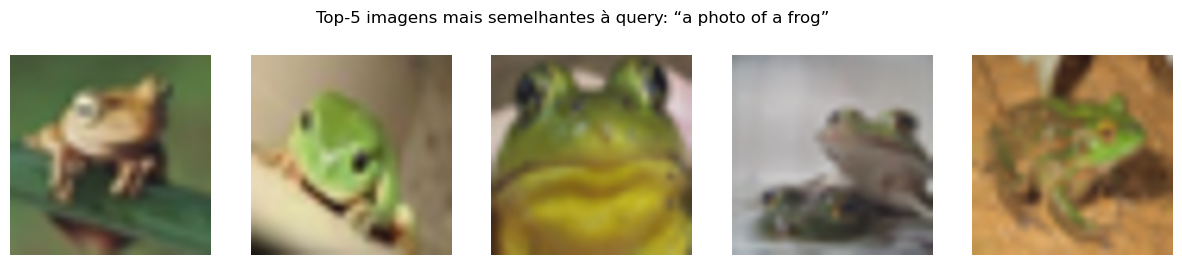

In [6]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    return torch.clamp(img, 0, 1)

query = "a photo of a frog"
query_token = tokenizer([query])
with torch.no_grad():
    query_emb = model.encode_text(query_token)
    query_emb /= query_emb.norm(dim=-1, keepdim=True)

similarities = (torch.tensor(image_embeddings) @ query_emb.T).squeeze()
top_indices = similarities.topk(5).indices

fig, axs = plt.subplots(1, 5, figsize=(15, 3))
for i, idx in enumerate(top_indices):
    img, _ = dataset[idx]
    img = denormalize(img)                                
    axs[i].imshow(np.transpose(img.numpy(), (1, 2, 0)))   
    axs[i].axis('off')
plt.suptitle(f"Top‑5 imagens mais semelhantes à query: “{query}”")
plt.show()

## 7. [Future Work]: Interpretação Visual e Comparativa entre CNNs e Vision Transformers
*(Possível extensão neste notebook ou ponto de partida para projeto dos estudantes)*

## 8. [Future Work]: Cartografia Estética e Semântica com CLIP
*(Possível extensão neste notebook ou ponto de partida para projeto dos estudantes)*

Explorar como diferentes arquiteturas de visão computacional — Redes Convolucionais (CNNs) e Vision Transformers (ViTs) — “olham” para uma imagem e quais as regiões que mais influenciam as suas decisões.

Pipeline sugerido:
	1.	Escolher um conjunto pequeno de imagens de teste (ex: flores, formas sintéticas, CIFAR-10).
	2.	Aplicar Grad-CAM a um modelo CNN (ex: ResNet-18) e Attention Rollout ao ViT (ex: ViT-B/16).
	3.	Visualizar e comparar os mapas de atenção de ambos os modelos sobre as mesmas imagens.
	4.	Quantificar a sobreposição entre mapas e máscaras verdadeiras (IoU, correlação espacial).
	5.	Avaliar o impacto de resolução, patch size e ruído na coerência dos mapas.
	6.	Refletir sobre o que estas diferenças revelam sobre estratégias de representação e explicabilidade visual.

Um estudo como este pode gerar resultados gráficos fortes, reproduzíveis e comparáveis, permitindo discutir atenção global vs. local, explicabilidade e transparência em modelos de visão.

Usar os embeddings visuais do CLIP para criar um “mapa estético” de imagens — uma representação espacial onde a proximidade reflete semelhança semântica e/ou visual.

Pipeline sugerido:
	1.	Selecionar um conjunto de imagens (ex: pinturas, fotografias, capas de revistas, posters).
	2.	Extrair embeddings CLIP (model.encode_image) e reduzi-los com PCA ou UMAP.
	3.	Projetar as imagens num plano 2D com thumbnails, observando agrupamentos espontâneos.
	4.	Investigar que fatores explicam a proximidade: conteúdo temático, paleta cromática, estilo visual, composição.
	5.	Criar trajetórias no espaço semântico (ex: de “paisagem natural” a “arquitetura urbana”) e visualizar a transição.
	6.	Opcional: comparar embeddings visuais e textuais (“a modern painting”, “a photograph of a mountain”) para analisar afinidade estética entre imagem e linguagem.

Um estudo como este permite refletir sobre como os modelos multimodais organizam o espaço visual, com implicações em curadoria algorítmica, crítica de arte computacional e interfaces de navegação estética.

## 9. Conclusão
Os modelos CLIP e ViT permitem capturar semântica visual e textual de forma integrada. Isto abre possibilidades para tarefas sem supervisão explícita, como classificação zero-shot ou busca multimodal, fundamentais em aplicações modernas.